In [1]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


### Retrieve data and build dataframse

In [3]:
from collections import defaultdict
import re

PROJECT_PATH = "jdm8943-rochester-institute-of-technology/final-style-prompt-gen"

runs = api.runs(PROJECT_PATH)

rows_results  = []
rows_baseline = []

for run in runs:
    if run.state != "finished":
        continue

    is_test     = bool(re.match(r"^test_trial\d+$",     run.name))
    is_baseline = bool(re.match(r"^baseline_trial\d+$", run.name))

    if not is_test and not is_baseline:
        continue

    datasource_data = defaultdict(dict)
    trial_metrics   = {}

    for k, v in run.summary.items():
        if k.startswith("_"):
            continue
        parts = k.split("/")

        if is_test:
            if k.startswith("test/") and len(parts) == 3:
                datasource_data[parts[1]][parts[2]] = v
            elif k.startswith("trial/") and len(parts) == 2:
                trial_metrics[parts[1]] = v
        elif is_baseline:
            if k.startswith("baseline/") and len(parts) == 3:
                datasource_data[parts[1]][parts[2]] = v

    for datasource, metrics in datasource_data.items():
        row = {
            "run_name":        run.name,
            "test_datasource": datasource,
            **metrics,
        }
        if is_test:
            row.update(trial_metrics)
            rows_results.append(row)
        else:
            rows_baseline.append(row)

results_df  = pd.DataFrame(rows_results)
baseline_df = pd.DataFrame(rows_baseline)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)


In [4]:
results_df

,run_name,test_datasource,bertscore_f1,bertscore_f1_std,bertscore_precision,bertscore_precision_std,bertscore_recall,bertscore_recall_std,chrf,chrf_std,dist1,dist2,inference_time_s,mean_cosine_sim,meteor,meteor_std,pred_semantic_sim,rougeL,rougeL_std,tag_f1_accent,tag_f1_accent_std,tag_f1_gender,tag_f1_gender_std,tag_f1_intrinsic_tags,tag_f1_intrinsic_tags_std,tag_f1_noise,tag_f1_noise_std,tag_f1_overall,tag_f1_overall_std,tag_f1_pitch,tag_f1_pitch_std,tag_f1_situational_tags,tag_f1_situational_tags_std,tag_f1_speaking_rate,tag_f1_speaking_rate_std,vec_norm_cv,vec_std,trainable_params,training_time_s,tag_f1_emotion,tag_f1_emotion_std,tag_f1_volume,tag_f1_volume_std
0,test_trial0,expresso,0.918784,0.012547,0.917267,0.013718,0.920412,0.014975,0.489574,0.077031,0.044158,0.168984,52.854468,0.519528,0.374768,0.107652,0.779824,0.380615,0.083090,0.860,0.346987,0.683333,0.463980,0.523303,0.332917,0.485000,0.499775,0.622292,0.186441,0.950,0.217945,0.320786,0.369351,0.426667,0.488944,0.011636,0.627600,133878029,3327.444776,NaN,NaN,NaN,NaN
1,test_trial0,styletalk,0.979400,0.013323,0.979459,0.014188,0.979360,0.013087,0.819222,0.117275,0.006000,0.010357,11.960417,0.846929,0.758437,0.131407,0.934686,0.730667,0.113106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.698333,0.304772,NaN,NaN,NaN,NaN,0.715000,0.451414,0.004633,0.339001,133878029,3327.444776,0.545000,0.497971,0.835000,0.371181
2,test_trial1,expresso,0.920882,0.011655,0.919322,0.012372,0.922541,0.014395,0.509333,0.071355,0.032585,0.113688,53.752994,0.555153,0.398197,0.107168,0.817718,0.391846,0.078824,0.950,0.217945,0.785000,0.410822,0.542133,0.330581,0.465000,0.498773,0.651213,0.179627,0.960,0.195959,0.352405,0.367601,0.408333,0.490394,0.005592,0.628033,133878029,3360.986334,NaN,NaN,NaN,NaN
3,test_trial1,styletalk,0.918152,0.010270,0.895851,0.012130,0.941764,0.014797,0.623389,0.072691,0.022930,0.045634,22.056420,0.728675,0.601282,0.112496,0.804968,0.448288,0.061181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.682103,0.271596,NaN,NaN,NaN,NaN,0.698333,0.457769,0.001628,0.424354,133878029,3360.986334,0.527667,0.458344,0.833333,0.371184
4,test_trial2,expresso,0.919432,0.013585,0.917572,0.014274,0.921386,0.015682,0.501946,0.079028,0.039458,0.157508,55.851887,0.523240,0.395217,0.117769,0.784544,0.394580,0.091001,0.860,0.346987,0.773333,0.417346,0.535119,0.301939,0.538333,0.497413,0.634619,0.172721,0.955,0.207304,0.333964,0.369475,0.368333,0.481199,0.030660,0.638566,133878029,3226.921125,NaN,NaN,NaN,NaN
5,test_trial2,styletalk,0.980126,0.013291,0.980095,0.014094,0.980175,0.013111,0.825462,0.116510,0.007333,0.013571,12.021699,0.791978,0.771916,0.135051,0.925100,0.743333,0.120692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.705000,0.290932,NaN,NaN,NaN,NaN,0.710000,0.453762,0.007835,0.366253,133878029,3226.921125,0.565000,0.495757,0.840000,0.366606
6,test_trial3,expresso,0.917044,0.012165,0.914907,0.012861,0.919268,0.014191,0.485222,0.072723,0.046154,0.185810,55.444910,0.515759,0.369362,0.107682,0.786757,0.376194,0.077844,0.895,0.306553,0.678333,0.465925,0.482540,0.320193,0.445000,0.496966,0.606577,0.183639,0.950,0.217945,0.324190,0.369758,0.443333,0.495659,0.000825,0.631574,133878029,3202.884858,NaN,NaN,NaN,NaN
7,test_trial3,styletalk,0.925460,0.015951,0.900473,0.021473,0.952047,0.013379,0.627459,0.093186,0.015699,0.038769,21.642196,0.832512,0.584094,0.130373,0.827694,0.454400,0.078612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676250,0.263216,NaN,NaN,NaN,NaN,0.710000,0.450074,0.003776,0.333765,133878029,3202.884858,0.520833,0.409925,0.835000,0.371181
8,test_trial4,expresso,0.915635,0.011251,0.912967,0.011739,0.918404,0.013952,0.483929,0.069354,0.046275,0.179280,53.044116,0.580038,0.368946,0.102230,0.789533,0.369640,0.080947,0.895,0.306553,0.675000,0.468375,0.459666,0.335383,0.435000,0.495757,0.595903,0.184217,0.940,0.237487,0.323238,0.378106,0.410000,0.491833,0.010592,0.557359,133878029,3153.060021,NaN,NaN,NaN,NaN
9,test_trial4,styletalk,0.919130,0.011057,0.897638,0.011681,0.941774,0.014032,0.631137,0.077706,0.013727,0.031995,20.70

In [5]:
baseline_df

,run_name,test_datasource,bertscore_f1,bertscore_f1_std,bertscore_precision,bertscore_precision_std,bertscore_recall,bertscore_recall_std,chrf,chrf_std,dist1,dist2,inference_time_s,meteor,meteor_std,pred_semantic_sim,rougeL,rougeL_std,tag_f1_accent,tag_f1_accent_std,tag_f1_gender,tag_f1_gender_std,tag_f1_intrinsic_tags,tag_f1_intrinsic_tags_std,tag_f1_noise,tag_f1_noise_std,tag_f1_overall,tag_f1_overall_std,tag_f1_pitch,tag_f1_pitch_std,tag_f1_situational_tags,tag_f1_situational_tags_std,tag_f1_speaking_rate,tag_f1_speaking_rate_std,tag_f1_emotion,tag_f1_emotion_std,tag_f1_volume,tag_f1_volume_std
0,baseline_trial0,expresso,0.896577,0.021741,0.895318,0.022892,0.897981,0.023189,0.401606,0.101305,0.087244,0.304476,165.765179,0.270447,0.114849,0.675436,0.303668,0.095066,0.715,0.451414,0.525,0.499375,0.394404,0.316495,0.385,0.486595,0.524737,0.223239,0.815,0.388298,0.421238,0.392067,0.380000,0.485386,NaN,NaN,NaN,NaN
1,baseline_trial0,styletalk,0.885585,0.018341,0.870056,0.018799,0.901850,0.021733,0.299460,0.094468,0.104409,0.347805,158.311841,0.219818,0.125305,0.638096,0.233919,0.096674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.174000,0.255259,NaN,NaN,NaN,NaN,0.130000,0.336303,0.148333,0.353864,0.120000,0.324962
2,baseline_trial1,expresso,0.903516,0.021141,0.902650,0.021221,0.904487,0.023161,0.430389,0.102099,0.082545,0.302978,159.691003,0.292717,0.115147,0.712757,0.321712,0.093875,0.760,0.427083,0.685,0.464516,0.455816,0.321999,0.385,0.486595,0.594622,0.223269,0.830,0.375633,0.504190,0.403748,0.410000,0.488433,NaN,NaN,NaN,NaN
3,baseline_trial1,styletalk,0.896013,0.022198,0.881778,0.023063,0.910924,0.025294,0.352488,0.126626,0.096906,0.315734,153.281702,0.268520,0.157080,0.664732,0.287696,0.116879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.263119,0.298836,NaN,NaN,NaN,NaN,0.295000,0.456043,0.165000,0.366663,0.190000,0.392301
4,baseline_trial2,expresso,0.902657,0.023129,0.902962,0.023020,0.902457,0.025145,0.415189,0.104085,0.078843,0.287097,172.502499,0.286226,0.115564,0.692542,0.319152,0.102451,0.765,0.423999,0.605,0.488851,0.404121,0.320592,0.450,0.497494,0.569155,0.218844,0.855,0.352101,0.443167,0.416891,0.350000,0.476970,NaN,NaN,NaN,NaN
5,baseline_trial2,styletalk,0.888356,0.019596,0.874091,0.019656,0.903233,0.022480,0.310753,0.103326,0.084655,0.288478,164.755175,0.238439,0.116197,0.665838,0.250968,0.101928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.198167,0.277733,NaN,NaN,NaN,NaN,0.165000,0.371181,0.148333,0.353864,0.165000,0.371181
6,baseline_trial3,expresso,0.906542,0.016018,0.904934,0.015723,0.908260,0.018934,0.443756,0.090657,0.073341,0.272806,165.168918,0.315844,0.112097,0.734354,0.337575,0.091094,0.765,0.423999,0.655,0.475368,0.439414,0.294809,0.430,0.495076,0.593642,0.192500,0.925,0.263391,0.436143,0.415460,0.410000,0.491833,NaN,NaN,NaN,NaN
7,baseline_trial3,styletalk,0.889609,0.017585,0.874114,0.017250,0.905801,0.021089,0.298934,0.089516,0.090737,0.298959,157.284450,0.226669,0.115049,0.659731,0.237417,0.084674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.137000,0.239972,NaN,NaN,NaN,NaN,0.055000,0.227980,0.090000,0.286182,0.160000,0.366606
8,baseline_trial4,expresso,0.906105,0.018279,0.905762,0.017757,0.906542,0.020957,0.431898,0.093281,0.075201,0.278960,172.361752,0.301987,0.108296,0.736547,0.328507,0.084780,0.775,0.417582,0.700,0.458258,0.443175,0.330562,0.520,0.499600,0.596743,0.210576,0.900,0.300000,0.463286,0.413570,0.345000,0.475368,NaN,NaN,NaN,NaN
9,baseline_trial4,styletalk,0.886751,0.020181,0.872674,0.021102,0.901412,0.021818,0.290927,0.092582,0.082351,0.282672,164.286660,0.215969,0.115638,0.686736,0.236740,0.100751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.126833,0.230668,NaN,NaN,NaN,NaN,0.155000,0.361905,0.100000,0.300000,0.045000,0.207304


In [6]:
def summarize(df, group_cols):
    drop_std_cols = [c for c in df.columns if c.endswith("_std")]
    agg_df = df.drop(columns=["run_name"] + drop_std_cols, errors="ignore")
    return agg_df.groupby(group_cols).agg(["mean", "std"]).round(4)

results_summary  = summarize(results_df,  ["test_datasource"])
baseline_summary = summarize(baseline_df, ["test_datasource"])


In [7]:
results_summary

bertscore_f1         bertscore_precision          \
                        mean     std                mean     std   
test_datasource                                                    
expresso              0.9185  0.0018              0.9164  0.0020   
styletalk             0.9470  0.0285              0.9352  0.0387   

                bertscore_recall            chrf           dist1          \
                            mean     std    mean     std    mean     std   
test_datasource                                                            
expresso                  0.9207  0.0017  0.4950  0.0108  0.0416  0.0053   
styletalk                 0.9595  0.0180  0.7165  0.0919  0.0132  0.0083   

                  dist2         inference_time_s         mean_cosine_sim  \
                   mean     std             mean     std            mean   
test_datasource                                                            
expresso         0.1603  0.0250          53.8589  1.0949          0.5329   
styletalk        0.0294  0.0209          18.1391  4.4971          0.8121   

                         meteor         pred_semantic_sim          rougeL  \
                    std    mean     std              mean     std    mean   
test_datasource                                                             
expresso         0.0444  0.3820  0.0151            0.7928  0.0120  0.3822   
styletalk        0.0499  0.6803  0.0817            0.8759  0.0564  0.5911   

                        tag_f1_accent         tag_f1_gender          \
                    std          mean     std          mean     std   
test_datasource                                                       
expresso         0.0107         0.887  0.0323        0.7272  0.0585   
styletalk        0.1315           NaN     NaN           NaN     NaN   

                tag_f1_intrinsic_tags         tag_f1_noise          \
                                 mean     std         mean     std   
test_datasource                                                      
expresso                       0.5122  0.0393       0.4747  0.0379   
styletalk                         NaN     NaN          NaN     NaN   

                tag_f1_overall         tag_f1_pitch          \
                          mean     std         mean     std   
test_datasource                                               
expresso                0.6242  0.0238        0.954  0.0077   
styletalk               0.6919  0.0172          NaN     NaN   

                tag_f1_situational_tags         tag_f1_speaking_rate          \
                                   mean     std                 mean     std   
test_datasource                                                                
expresso                         0.3395  0.0141               0.4050  0.0328   
styletalk                           NaN     NaN               0.7058  0.0058   

                vec_norm_cv         trainable_params      training_time_s  \
                       mean     std             mean  std            mean   
test_datasource                                                             
expresso             0.0288  0.0229      133878029.0  0.0        3204.783   
styletalk            0.0115  0.0207      133878029.0  0.0        3204.783   

                         tag_f1_emotion         tag_f1_volume          
                     std           mean     std          mean     std  
test_datasource                                                        
expresso         78.6929            NaN     NaN           NaN     NaN  
styletalk        78.6929         0.5429  0.0454        0.8362  0.0058

In [8]:
baseline_summary

bertscore_f1         bertscore_precision          \
                        mean     std                mean     std   
test_datasource                                                    
expresso              0.9031  0.0048              0.9025  0.0049   
styletalk             0.8884  0.0046              0.8739  0.0053   

                bertscore_recall            chrf           dist1          \
                            mean     std    mean     std    mean     std   
test_datasource                                                            
expresso                  0.9038  0.0048  0.4220  0.0193  0.0773  0.0081   
styletalk                 0.9037  0.0039  0.3106  0.0207  0.0944  0.0100   

                  dist2         inference_time_s           meteor          \
                   mean     std             mean      std    mean     std   
test_datasource                                                             
expresso         0.2861  0.0186         175.5219  17.2739  0.2898  0.0173   
styletalk        0.3105  0.0216         167.7841  16.7590  0.2340  0.0183   

                pred_semantic_sim          rougeL         tag_f1_accent  \
                             mean     std    mean     std          mean   
test_datasource                                                           
expresso                   0.7105  0.0525  0.3200  0.0168        0.7435   
styletalk                  0.6472  0.0527  0.2485  0.0206           NaN   

                        tag_f1_gender        tag_f1_intrinsic_tags          \
                    std          mean    std                  mean     std   
test_datasource                                                              
expresso         0.0561         0.627  0.065                0.4268  0.0371   
styletalk           NaN           NaN    NaN                   NaN     NaN   

                tag_f1_noise         tag_f1_overall         tag_f1_pitch  \
                        mean     std           mean     std         mean   
test_datasource                                                            
expresso              0.4525  0.0445          0.579  0.0417       0.8705   
styletalk                NaN     NaN          0.180  0.0442          NaN   

                        tag_f1_situational_tags         tag_f1_speaking_rate  \
                    std                    mean     std                 mean   
test_datasource                                                                
expresso         0.0594                   0.458  0.0594               0.3892   
styletalk           NaN                     NaN     NaN               0.1483   

                        tag_f1_emotion         tag_f1_volume          
                    std           mean     std          mean     std  
test_datasource                                                       
expresso         0.0273            NaN     NaN           NaN     NaN  
styletalk        0.0619         0.1325  0.0359        0.1513  0.0537

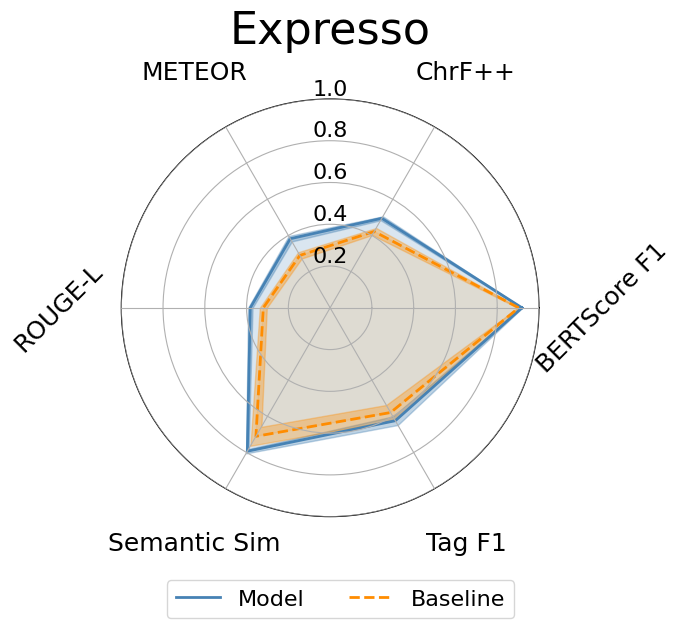

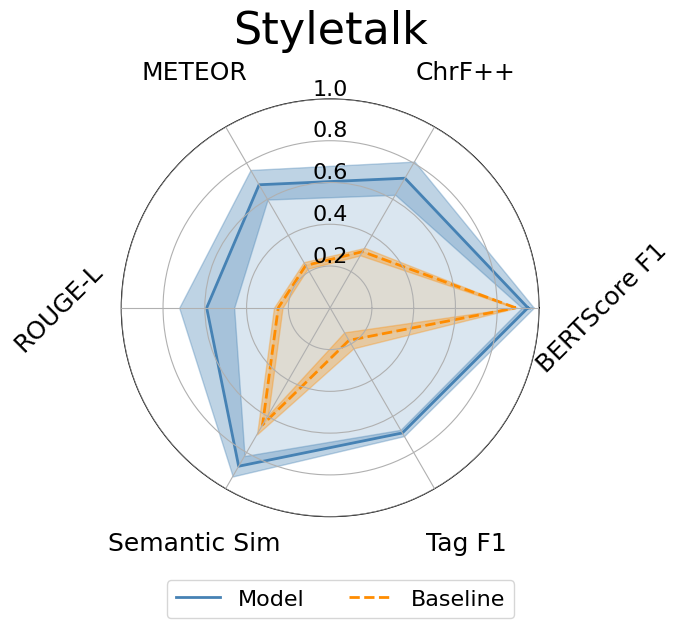

In [9]:
import numpy as np

METRICS = {
    "BERTScore F1": "bertscore_f1",
    "ChrF++": "chrf",
    "METEOR": "meteor",
    "ROUGE-L": "rougeL",
    "Semantic Sim": "pred_semantic_sim",
    "Tag F1": "tag_f1_overall",
}




def radar_plot(datasource, results_summary, baseline_summary):
    labels = list(METRICS.keys())
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    def get_vals(summary_df):
        row = summary_df.loc[datasource]
        means = [float(row[(col, "mean")]) for col in METRICS.values()]
        stds  = [float(row[(col, "std")])  for col in METRICS.values()]
        return means + means[:1], stds + stds[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    ax.set_axisbelow(False)


    test_vals, test_stds   = get_vals(results_summary)
    base_vals, base_stds   = get_vals(baseline_summary)

    test_vals  = np.array(test_vals);  test_stds  = np.array(test_stds)
    base_vals  = np.array(base_vals);  base_stds  = np.array(base_stds)

    h1, = ax.plot(angles, test_vals, color="steelblue", linewidth=2, label="Model")
    ax.fill_between(angles, test_vals - test_stds, test_vals + test_stds,
                    color="steelblue", alpha=0.35)
    ax.fill(angles, test_vals, color="steelblue", alpha=0.2)

    h2, = ax.plot(angles, base_vals, color="darkorange", linewidth=2, linestyle="--", label="Baseline")
    ax.fill_between(angles, base_vals - base_stds, base_vals + base_stds,
                    color="darkorange", alpha=0.32)
    ax.fill(angles, base_vals, color="darkorange", alpha=0.12)


    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])  # suppress auto labels

    for i, (angle, label) in enumerate(zip(angles[:-1], labels)):
        rotation = 45 if i == 0 or i==3 else 0
        ax.text(angle, 1.3, label,
                ha='center', va='center',
                rotation=rotation, fontsize=18,
                transform=ax.get_xaxis_transform())


    ax.set_ylim(0, 1)
    ax.set_rlabel_position(90)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('center')

    ax.set_title(datasource.capitalize(), size=32, pad=40)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', pad=34)


    fig.legend(handles=[h1, h2], loc="lower center", ncol=2,
               fontsize=16, bbox_to_anchor=(0.5, -0.08), frameon=True)

    fig.subplots_adjust(top=0.75)

    plt.tight_layout()
    plt.show()

for ds in ["expresso", "styletalk"]:
    radar_plot(ds, results_summary, baseline_summary)


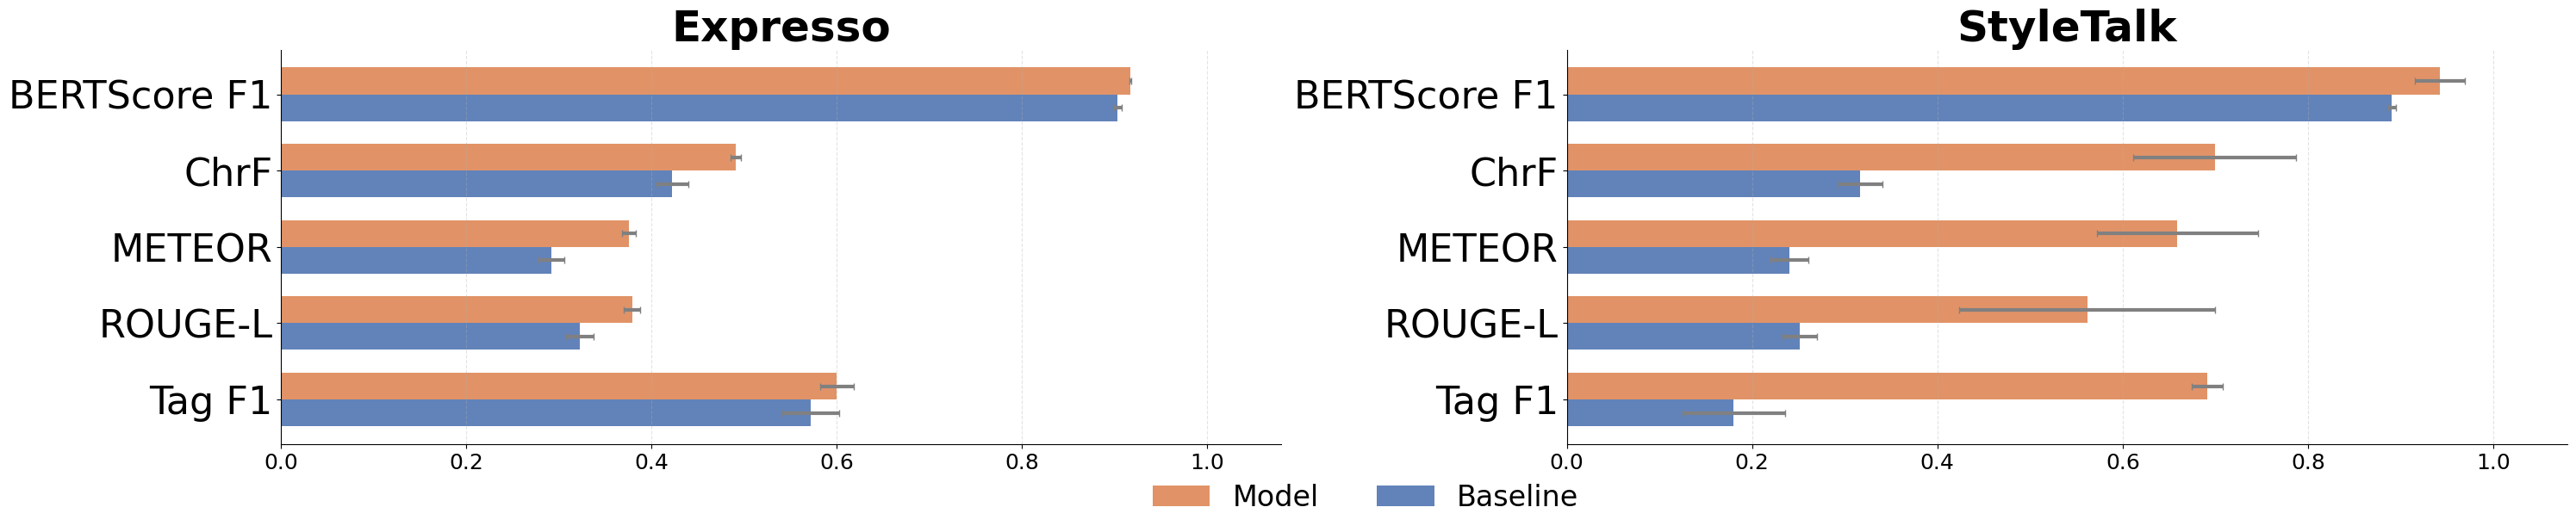

In [94]:
import numpy as np

METRICS = {
    "expresso": [
        ("bertscore_f1",         "BERTScore F1"),
        ("chrf",                 "ChrF"),
        ("meteor",               "METEOR"),
        ("rougeL",               "ROUGE-L"),
        ("tag_f1_overall",       "Tag F1"),
    ],
    "styletalk": [
        ("bertscore_f1",         "BERTScore F1"),
        ("chrf",                 "ChrF"),
        ("meteor",               "METEOR"),
        ("rougeL",               "ROUGE-L"),
        ("tag_f1_overall",       "Tag F1")
    ],
}

FONT = {
    "title":       36,
    "suptitle":    36,
    "axis_label":  22,
    "tick_label":  32,
    "legend":      24,
    "x_tick":      18,

}

DATASET_LABELS = {"expresso": "Expresso", "styletalk": "StyleTalk"}
BASELINE_COLOR    = "#4C72B0"
MODEL_COLOR = "#DD8452"

fig, axes = plt.subplots(1, 2, figsize=(30, 6), sharey=False)

for ax, (dataset, metric_pairs) in zip(axes, METRICS.items()):
    keys   = [k   for k, _   in metric_pairs]
    labels = [lbl for _, lbl in metric_pairs]

    model_means, model_stds = [], []
    base_means,  base_stds  = [], []

    for key in keys:
        def _get(summary, ds, col, stat):
            try:
                return float(summary.loc[ds, (col, stat)])
            except KeyError:
                return float("nan")

        model_means.append(_get(results_summary,  dataset, key, "mean"))
        model_stds .append(_get(results_summary,  dataset, key, "std"))
        base_means .append(_get(baseline_summary, dataset, key, "mean"))
        base_stds  .append(_get(baseline_summary, dataset, key, "std"))

    n     = len(keys)
    y     = np.arange(n)
    bar_h = 0.35

    ax.barh(y - bar_h / 2, model_means, bar_h,
            xerr=model_stds, label="Model",
            color=MODEL_COLOR, alpha=0.88,
            error_kw=dict(elinewidth=3, capsize=3, ecolor="grey"))
    ax.barh(y + bar_h / 2, base_means, bar_h,
            xerr=base_stds, label="Baseline",
            color=BASELINE_COLOR, alpha=0.88,
            error_kw=dict(elinewidth=3, capsize=3, ecolor="grey"))

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=FONT["tick_label"])
    # ax.set_xlabel("Score",     fontsize=FONT["axis_label"])
    ax.tick_params(axis="x", labelsize=FONT["x_tick"])

    ax.set_title(DATASET_LABELS[dataset], fontsize=FONT["title"], fontweight="semibold")
    ax.set_xlim(0, 1.08)
    ax.invert_yaxis()
    
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=FONT["legend"], frameon=False,
           bbox_to_anchor=(0.53, -0.05))

# fig.suptitle("Model vs Baseline — Per Dataset", fontsize=FONT["suptitle"], fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()


Test runs: 10, Baseline runs: 10


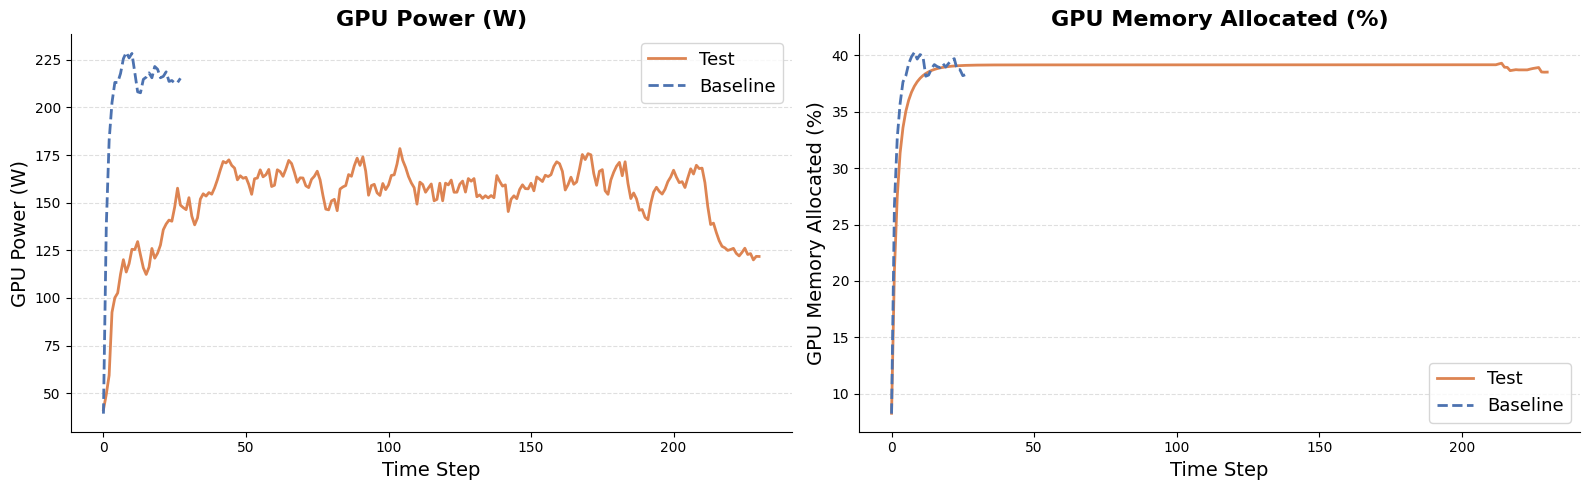

In [11]:
import re

power_col = "system.gpu.0.powerWatts"
mem_col   = "system.gpu.0.memoryAllocated"

SMOOTH_SPAN = 10
BASELINE_COLOR    = "#4C72B0"
MODEL_COLOR = "#DD8452"
def smooth(s, span=SMOOTH_SPAN):
    return s.dropna().reset_index(drop=True).ewm(span=span, min_periods=1).mean()

test_sys, baseline_sys = [], []
seen_runs = set()

for run in api.runs(PROJECT_PATH):
    if run.state != "finished" or run.name in seen_runs:
        continue
    is_test     = bool(re.match(r"^test_trial\d+$",     run.name))
    is_baseline = bool(re.match(r"^baseline_trial\d+$", run.name))
    if not is_test and not is_baseline:
        continue
    seen_runs.add(run.name)

    full_run = api.run("/".join(run.path))
    df = pd.DataFrame(full_run.history(stream="system"))
    if df.empty:
        continue

    if is_test:
        test_sys.append(df)
    else:
        baseline_sys.append(df)

print(f"Test runs: {len(test_sys)}, Baseline runs: {len(baseline_sys)}")


def align_and_mean(dfs, col):
    """Interpolate each run to a common time index, then average."""
    series = [smooth(df[col].reset_index(drop=True)) for df in dfs if col in df.columns]
    if not series:
        return pd.Series(dtype=float)
    max_len = max(len(s) for s in series)
    reindexed = [
        s.reindex(range(max_len)).interpolate(limit_direction="both")
        for s in series
    ]
    return pd.concat(reindexed, axis=1).mean(axis=1)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_cfg = [
    (power_col, "GPU Power (W)",          axes[0]),
    (mem_col,   "GPU Memory Allocated (%)", axes[1]),
]

for col, ylabel, ax in plot_cfg:
    test_mean = align_and_mean(test_sys,     col)
    base_mean = align_and_mean(baseline_sys, col)

    if not test_mean.empty:
        ax.plot(test_mean.index, test_mean.values,
                color=MODEL_COLOR, linewidth=2, label="Test")
    if not base_mean.empty:
        ax.plot(base_mean.index, base_mean.values,
                color=BASELINE_COLOR, linewidth=2, linestyle="--", label="Baseline")

    ax.set_xlabel("Time Step", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(ylabel, fontsize=16, fontweight="semibold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=13)

plt.tight_layout()
plt.show()
